# PIKAN prediction for the semi-infinite-domain problem

Train a PIKAN with the tuned infinite-domain KAN configuration, then compare the semi-infinite prediction with its analytical solution and coefficient.

## Reproducible setup

Import the semi-infinite problem definition and PINN/KAN training utilities.

In [32]:
import numpy as np

In [37]:
from pathlib import Path
import sys
from importlib import reload

import matplotlib.pyplot as plt
import numpy as np
import torch

notebook_dir = Path.cwd().resolve()
repo_root = next(
    (path for path in [notebook_dir, *notebook_dir.parents] if (path / "utils").is_dir()),
    notebook_dir,
)
utilities_dir = repo_root / "utils"
if str(utilities_dir) not in sys.path:
    sys.path.insert(0, str(utilities_dir))

import pinns_infinite
import pinns_semi_infinite
import semi_infinite
reload(semi_infinite)
reload(pinns_infinite)
reload(pinns_semi_infinite)

from pinns_semi_infinite import build_models_KAN, set_seed, train_dual_network_semi_inf
from semi_infinite import (
    analytical_solution_semi_inf,
    coefficient_semi_inf,
    evaluate_model_semi_inf,
)

set_seed(2)
torch.set_default_dtype(torch.float32)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Tuned PIKAN configuration

Use the best recorded infinite-domain KAN configuration as the initial semi-infinite experiment.

In [ ]:
config = {
    "hidden_layers": 3,
    "hidden_units": 25,
    "grid_size": 5,
    "spline_order": 3,
    "adam_lr": 1e-3,
    "adam_iters": 2000,
    "lbfgs_iters": 2000,
    "sampling": "gaussian_exponential",
    "sigma": 5.5,
    "exp_scale": 7.0,
    "n_obs_u": 100,
    "n_boundary_u": 10,
    "n_obs_k": 100,
    "n_pde": 1000,
    "seed": 2,
    "pde_alpha": 0.5,
    "pde_beta": 5.0,
    "epsilon": 1.0,
    "train_domain": (-5.0, 5.0, -5.0, 0.0),
    "eval_domain": (-8.0, 8.0, -8.0, 0.0),
}

for name, value in config.items():
    print(f"{name}: {value}")

hidden_layers: 3
hidden_units: 25
grid_size: 5
spline_order: 3
adam_lr: 0.001
adam_iters: 2000
lbfgs_iters: 2000
sampling: gaussian_exponential
sigma: 5.5
exp_scale: 7.0
n_obs_u: 100
n_boundary_u: 100
n_obs_k: 100
n_pde: 1000
seed: 2
pde_alpha: 0.5
pde_beta: 5.0
epsilon: 1.0
train_domain: (-5.0, 5.0, -5.0, 0.0)
eval_domain: (-8.0, 8.0, -8.0, 0.0)


## Build the KAN models

The two KANs learn the solution $u(x,y)$ and variable coefficient $k(y)$ jointly.

In [35]:
model_u, model_k = build_models_KAN(
    device=device,
    hidden_layers=config["hidden_layers"],
    hidden_units=config["hidden_units"],
    grid_size=config["grid_size"],
    spline_order=config["spline_order"],
)

print(model_u)
print(model_k)

KAN(
  (layers): ModuleList(
    (0-3): 4 x KANLinear(
      (base_activation): SiLU()
    )
  )
)
KAN(
  (layers): ModuleList(
    (0-3): 4 x KANLinear(
      (base_activation): SiLU()
    )
  )
)


## Train the semi-infinite PIKAN

This cell runs the same 2,000-step Adam and 2,000-step L-BFGS schedule used for the tuned infinite-domain configuration.

In [38]:
results_dir = repo_root / "main" / "simple_prediction" / "results"

history = train_dual_network_semi_inf(
    model_u,
    model_k,
    adam_lr=config["adam_lr"],
    adam_iters=config["adam_iters"],
    lbfgs_iters=config["lbfgs_iters"],
    verbose=True,
    print_every=100,
    save_every=100,
    lambda_pde_scheduler=True,
    adaptive_weights=True,
    alpha=7,
    update_every=100,
    regularization=False,
    sampling=config["sampling"],
    sigma=config["sigma"],
    exp_scale=config["exp_scale"],
    n_obs_u=config["n_obs_u"],
    n_boundary_u=config["n_boundary_u"],
    n_obs_k=config["n_obs_k"],
    n_pde=config["n_pde"],
    seed=config["seed"],
    save_results=True,
    base_dir=str(results_dir),
    run_name="pikan_semi_infinite_tuned",
    pde_alpha=config["pde_alpha"],
    pde_beta=config["pde_beta"],
    epsilon=config["epsilon"],
    device=device,
)


Training with Adam
Adam     0 | Total=4.790e+00 | ObsU=2.307e-02 | ObsK=2.537e+00 | PDE=2.231e+01 | Ratio=109.94 | ErrU=9.936e-01 | ErrK=9.991e-01
V      = [0.023 2.537]
R      = [0. 1.]
ratio  = 109.94
lambda_u = 1.000
lambda_k = 84.960
lambda_pde = 0.100
Adam   100 | Total=2.552e+00 | ObsU=2.294e-02 | ObsK=3.228e-01 | PDE=2.206e+01 | Ratio=109.94 | ErrU=9.996e-01 | ErrK=3.598e-01
V      = [0.023 1.43 ]
R      = [0. 1.]
ratio  = 62.14
lambda_u = 1.000
lambda_k = 51.497
lambda_pde = 0.100
Adam   200 | Total=3.572e+00 | ObsU=1.711e-02 | ObsK=3.033e-02 | PDE=9.786e+00 | Ratio=62.14 | ErrU=8.687e-01 | ErrK=1.094e-01
V      = [0.021 0.963]
R      = [0. 1.]
ratio  = 45.78
lambda_u = 1.000
lambda_k = 40.045
lambda_pde = 0.100
Adam   300 | Total=6.764e-01 | ObsU=1.712e-02 | ObsK=6.729e-03 | PDE=3.128e+00 | Ratio=45.78 | ErrU=8.427e-01 | ErrK=5.164e-02
V      = [0.02  0.724]
R      = [0. 1.]
ratio  = 36.10
lambda_u = 1.000
lambda_k = 33.267
lambda_pde = 0.250
Adam   400 | Total=3.036e-01 | Ob

## Evaluate against the analytical solution

The training domain is $[-5,5]\times[-5,0]$ and the larger evaluation window is $[-8,8]\times[-8,0]$.

In [39]:
evaluation = evaluate_model_semi_inf(
    model_u=model_u,
    model_k=model_k,
    analytical_solution=analytical_solution_semi_inf,
    coefficient=coefficient_semi_inf,
    train_domain=config["train_domain"],
    eval_domain=config["eval_domain"],
    n_grid=400,
    alpha=config["pde_alpha"],
    beta=config["pde_beta"],
    epsilon=config["epsilon"],
    device=device,
    verbose=True,
)

metric_names = [
    "err_u_global", "err_k_global",
    "err_u_inside", "err_k_inside",
    "err_u_outside", "err_k_outside",
]
metrics = {name: float(evaluation[name]) for name in metric_names}
metrics

Semi-infinite-domain spatial generalization (MAE)
u (global): 4.326e-03
k (global): 9.246e-04
u (inside): 4.342e-03
k (inside): 8.306e-04
u (outside): 4.315e-03
k (outside): 9.848e-04


{'err_u_global': 0.004325610333373444,
 'err_k_global': 0.0009245634058072429,
 'err_u_inside': 0.004341629685017989,
 'err_k_inside': 0.0008306230731983915,
 'err_u_outside': 0.004315341518216685,
 'err_k_outside': 0.000984781567735994}

## Visual comparison

Compare the analytical fields, PIKAN predictions, and absolute errors.

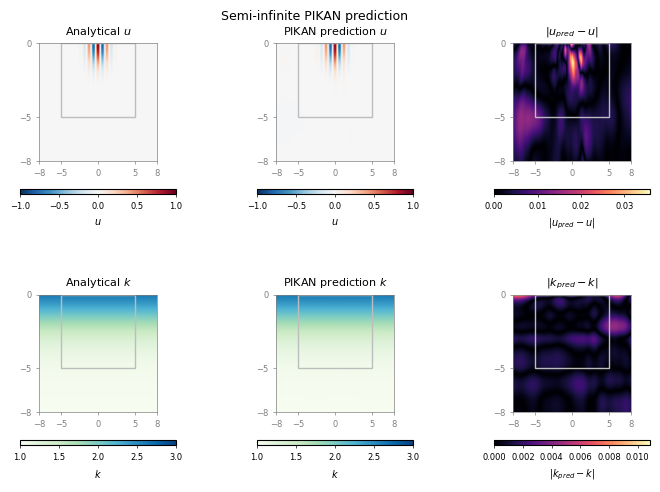

Saved weights and metadata to: /home/orincon/unbounded-domains/main/simple_prediction/results/pikan_semi_infinite_tuned_weights.pt


In [42]:
X = evaluation["X"]
Y = evaluation["Y"]
U_exact = analytical_solution_semi_inf(X, Y, config["pde_alpha"], config["pde_beta"])
K_exact = coefficient_semi_inf(X, Y, config["epsilon"])
U_pred = evaluation["U_pred"]
K_pred = evaluation["K_pred"]

train_xmin, train_xmax, train_ymin, train_ymax = config["train_domain"]
eval_xmin, eval_xmax, eval_ymin, eval_ymax = config["eval_domain"]
extent = [eval_xmin, eval_xmax, eval_ymin, eval_ymax]

fig, axes = plt.subplots(2, 3, figsize=(7.0, 4.8))

panels = [
    (U_exact, "Analytical $u$", "RdBu_r", -1, 1, r"$u$"),
    (U_pred, "PIKAN prediction $u$", "RdBu_r", -1, 1, r"$u$"),
    (np.abs(U_pred - U_exact), r"$|u_{pred}-u|$", "magma", 0, None, r"$|u_{pred}-u|$"),
    (K_exact, "Analytical $k$", "GnBu", 1, 3, r"$k$"),
    (K_pred, "PIKAN prediction $k$", "GnBu", 1, 3, r"$k$"),
    (np.abs(K_pred - K_exact), r"$|k_{pred}-k|$", "magma", 0, None, r"$|k_{pred}-k|$"),
]

for axis, (values, title, cmap, vmin, vmax, colorbar_label) in zip(axes.ravel(), panels):
    image = axis.imshow(
        values,
        extent=extent,
        origin="lower",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        aspect="auto",
    )
    axis.add_patch(
        plt.Rectangle(
            (train_xmin, train_ymin),
            train_xmax - train_xmin,
            train_ymax - train_ymin,
            fill=False,
            edgecolor="#BDBDBD",
            linewidth=1.0,
        )
    )
    axis.set_box_aspect(1)
    axis.set_xlim(eval_xmin, eval_xmax)
    axis.set_ylim(eval_ymin, eval_ymax)
    axis.set_title(title, fontsize=8)
    axis.set_xticks([eval_xmin, -5, 0, 5, eval_xmax])
    axis.set_yticks([eval_ymin, -5, 0])
    axis.tick_params(labelsize=6, length=2, width=0.5, colors="gray")
    for spine in axis.spines.values():
        spine.set_color("gray")
        spine.set_linewidth(0.5)
    colorbar = fig.colorbar(
        image,
        ax=axis,
        orientation="horizontal",
        fraction=0.045,
        pad=0.18,
        aspect=28,
    )
    colorbar.set_label(colorbar_label, fontsize=7)
    colorbar.ax.tick_params(labelsize=6, length=2, width=0.5)

fig.suptitle("Semi-infinite PIKAN prediction", fontsize=9, y=0.99)
fig.subplots_adjust(left=0.08, right=0.98, bottom=0.08, top=0.92, wspace=0.52, hspace=0.65)
plt.show()

weights_path = results_dir / "pikan_semi_infinite_tuned_weights.pt"
torch.save(
    {
        "model_u": model_u.state_dict(),
        "model_k": model_k.state_dict(),
        "config": config,
        "metrics": metrics,
    },
    weights_path,
)
print(f"Saved weights and metadata to: {weights_path}")